# XGBoost Crop Classification for Morocco

This notebook trains and evaluates an **XGBoost multiclass classifier** for Moroccan crop/land-cover classification using Sentinel-2 spectral bands and vegetation/soil/water indices.

## Objective
Build a clean, reproducible machine-learning workflow that predicts one of the following consolidated classes:

- `wheat`
- `corn`
- `soil`
- `other_crop`

## What this notebook does
1. Loads label and feature CSV files from Google Drive.
2. Cleans and consolidates crop labels into modeling classes.
3. Performs exploratory data analysis and quality checks.
4. Clips spectral bands to reduce the influence of extreme outliers.
5. Engineers additional spectral indices and ratios.
6. Trains a weighted XGBoost classifier.
7. Tunes the XGBoost model with randomized search and stratified cross-validation.
8. Evaluates model performance with metrics and visualizations.
9. Saves the trained model and preprocessing artifacts for reuse.

> The modeling concept, target mapping, features, and XGBoost approach are preserved. The notebook has been reorganized and documented for clarity and professionalism.


## 1. Environment Setup

This section mounts Google Drive and imports the libraries used throughout the notebook.


In [1]:
# Mount Google Drive when running in Google Colab.
# If you are running locally, you can skip this cell and update BASE_PATH below.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as error:
    print('Google Drive mount skipped. This is expected outside Google Colab.')
    print(f'Details: {error}')


Mounted at /content/drive


In [2]:
import os
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

RANDOM_STATE = 42


## 2. Configuration

All project paths, class mappings, and reusable feature lists are defined in one place so the workflow is easier to maintain.


In [3]:
BASE_PATH = Path('/content/drive/MyDrive/Crop and irrigation type dataset for Moroccan')
OUTPUT_DIR = Path('/content/drive/MyDrive/morocco_clean_outputs')

LABELS_FILE = BASE_PATH / 'morocco_labels_with_features.csv'
FEATURES_FILE = BASE_PATH / 'morocco_field_features.csv'

CROP_MAP = {
    'Wheat': 'wheat',
    'Corn': 'corn',
    'Bare soil': 'soil',
    'Alfalfa': 'other_crop',
    'Beets': 'other_crop',
    'Potatoes': 'other_crop',
    'Tomatoes': 'other_crop',
    'Sugarcane': 'other_crop',
    'Rice': 'other_crop',
    'Beans': 'other_crop',
}

BAND_COLS = [
    'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7',
    'B8', 'B8A', 'B9', 'B11', 'B12', 'NDVI'
]

REFLECTANCE_COLS = [
    'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7',
    'B8', 'B8A', 'B9', 'B11', 'B12'
]

COMMON_FEATURE_COLS = [
    'B2', 'B3', 'B4', 'B5', 'B6', 'B7',
    'B8', 'B8A', 'B11', 'NDVI'
]


## 3. Helper Functions

These helper functions keep the notebook readable while preserving the original modeling logic.


In [4]:
def preview_directory(path: Path, limit: int = 20) -> None:
    """Print a short preview of files/folders in a directory."""
    if not path.exists():
        print(f'Path does not exist: {path}')
        return
    items = sorted(os.listdir(path))[:limit]
    print(f'Preview of {path}:')
    for item in items:
        print(f'- {item}')


def load_input_data(labels_path: Path, features_path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load labels and feature tables from CSV files."""
    labels = pd.read_csv(labels_path)
    features = pd.read_csv(features_path)
    print(f'labels_df shape:   {labels.shape}')
    print(f'features_df shape: {features.shape}')
    return labels, features


def apply_class_mapping(df: pd.DataFrame, crop_map: dict, label_col: str = 'label') -> pd.DataFrame:
    """Filter supported labels and create the consolidated modeling class column."""
    cleaned = df[df[label_col].isin(crop_map.keys())].copy()
    cleaned['class'] = cleaned[label_col].map(crop_map)
    return cleaned


def plot_value_counts(series: pd.Series, title: str, xlabel: str, ylabel: str = 'Count') -> None:
    """Plot a clean bar chart for categorical counts."""
    counts = series.value_counts()
    ax = counts.plot(kind='bar', figsize=(8, 4))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()


def plot_missing_values(df: pd.DataFrame, title: str = 'Missing Values by Column') -> None:
    """Visualize columns that contain missing values."""
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    if missing.empty:
        print('No missing values found.')
        return
    ax = missing.plot(kind='bar', figsize=(10, 4))
    ax.set_title(title)
    ax.set_xlabel('Column')
    ax.set_ylabel('Missing values')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title: str) -> pd.DataFrame:
    """Create a confusion matrix table and plot."""
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    display(cm_df)

    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
        ax=ax,
        values_format='d',
        cmap='Blues',
        colorbar=False,
    )
    ax.set_title(title)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    return cm_df


def plot_feature_importance(model, feature_names: list[str], top_n: int = 20) -> pd.DataFrame:
    """Return and visualize feature importance from an XGBoost model."""
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    importance['rank'] = importance.index + 1

    plot_data = importance.head(top_n).sort_values('importance')
    ax = plot_data.plot(kind='barh', x='feature', y='importance', figsize=(8, 6), legend=False)
    ax.set_title(f'Top {min(top_n, len(importance))} Feature Importances')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()
    return importance


## 4. Data Loading

Load the raw labels table and field-level feature table from Google Drive.


In [5]:
preview_directory(Path('/content/drive/MyDrive'))
preview_directory(BASE_PATH)

labels_df, features_df = load_input_data(LABELS_FILE, FEATURES_FILE)


Preview of /content/drive/MyDrive:
- .txt
- Classroom
- Colab Notebooks
- Crop and irrigation type dataset for Moroccan
- Emb_Task_four_7_segment.pdf
- Embedded_Tasks2&3.7z
- Esraa Lec 5.pdf
- Esraa Lec 6.pdf
- Google AI Studio
- Laila’s Escape Project.pptx
- Lect.2.pdf
- Logistic Regression.pdf
- Logistic Regression.pptx
- ML D2S2 - Copy.gslides
- New Text Document (3).txt
- Python_Lab1_iti.ipynb
- Python_Lab2_iti.ipynb
- Recordings_LECs
- Representation Learning Lec_6
- Robotics and intelligent system_lab2.pdf
Preview of /content/drive/MyDrive/Crop and irrigation type dataset for Moroccan:
- Features
- Photos
- morocco_field_features.csv
- morocco_labels_with_features.csv
labels_df shape:   (7124, 9)
features_df shape: (7124, 17)


## 5. Class Cleaning and Consolidation

The original crop labels are consolidated into four modeling classes. This keeps the original notebook concept unchanged while making the target classes clearer.


In [6]:
labels_clean = apply_class_mapping(labels_df, CROP_MAP)
features_clean = apply_class_mapping(features_df, CROP_MAP)

print('Labels before:', len(labels_df))
print('Labels after: ', len(labels_clean))
display(labels_clean['class'].value_counts().to_frame('label_count'))

print('\nFeatures before:', len(features_df))
print('Features after: ', len(features_clean))
display(features_clean['class'].value_counts().to_frame('feature_count'))


Labels before: 7124
Labels after:  6762


,label_count
class,
wheat,2614
other_crop,1954
corn,1252
soil,942



Features before: 7124
Features after:  6762


,feature_count
class,
wheat,2614
other_crop,1954
corn,1252
soil,942


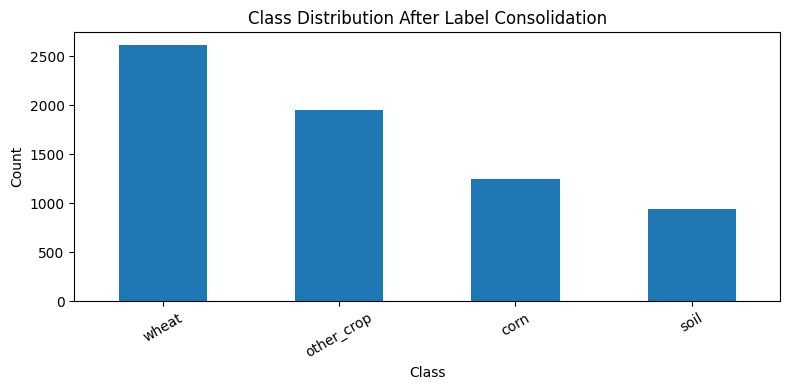

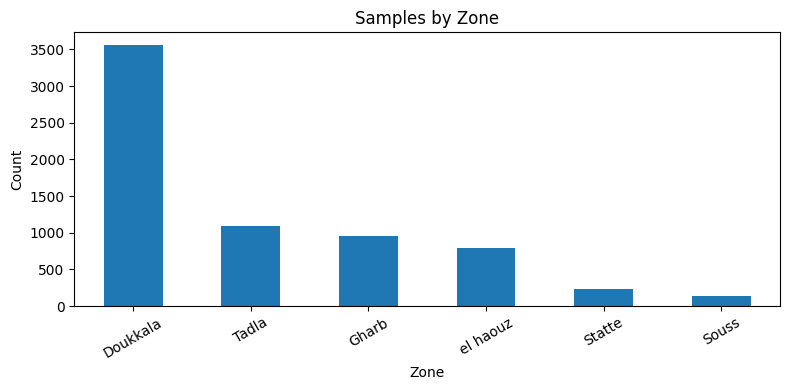

In [7]:
plot_value_counts(features_clean['class'], 'Class Distribution After Label Consolidation', 'Class')

if 'zone' in features_clean.columns:
    plot_value_counts(features_clean['zone'], 'Samples by Zone', 'Zone')


## 6. Data Quality and Exploratory Analysis

This section checks the structure of the dataset, missing values, class distribution, feature ranges, and basic spectral patterns.


In [8]:
display(features_clean.head())
features_clean.info()


,parcel_id,B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12,NDVI,label,irrigation,zone,class
0,Doukkala_Bare soil_20240422_001,693.910646,798.593839,1032.651913,1372.857879,1572.294307,1707.351335,1851.199900,1979.984908,2083.750643,2143.399064,3635.551078,3346.747934,0.175744,Bare soil,NaN,Doukkala,soil
1,Doukkala_Bare soil_20240422_002,575.155528,648.792568,831.243794,1116.201914,1253.635502,1313.222512,1426.336494,1532.162035,1623.097112,1691.744238,2992.218838,2674.412796,0.157796,Bare soil,NaN,Doukkala,soil
2,Doukkala_Bare soil_20240422_003,546.627750,664.185252,865.152208,1174.222899,1315.857456,1382.017717,1495.075454,1611.860684,1691.850485,1698.947775,3127.308801,2854.226014,0.159373,Bare soil,NaN,Doukkala,soil
3,Doukkala_Bare soil_20240422_004,616.803138,713.456019,872.989335,1136.961460,1267.397322,1322.086087,1437.508268,1556.929807,1643.293917,1687.350183,2978.173760,2624.535998,0.157235,Bare soil,NaN,Doukkala,soil
4,Doukkala_Bare soil_20240422_005,525.693636,621.642510,844.452495,1213.038946,1364.782677,1431.619799,1553.620342,1675.869979,1756.679144,1787.436389,3237.494094,2941.674181,0.162244,Bare soil,NaN,Doukkala,soil


<class 'pandas.core.frame.DataFrame'>
Index: 6762 entries, 0 to 7107
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   parcel_id   6762 non-null   object 
 1   B1          6762 non-null   float64
 2   B2          6762 non-null   float64
 3   B3          6762 non-null   float64
 4   B4          6762 non-null   float64
 5   B5          6762 non-null   float64
 6   B6          6762 non-null   float64
 7   B7          6762 non-null   float64
 8   B8          6762 non-null   float64
 9   B8A         6762 non-null   float64
 10  B9          6762 non-null   float64
 11  B11         6762 non-null   float64
 12  B12         6762 non-null   float64
 13  NDVI        6762 non-null   float64
 14  label       6762 non-null   object 
 15  irrigation  5838 non-null   object 
 16  zone        6762 non-null   object 
 17  class       6762 non-null   object 
dtypes: float64(13), object(5)
memory usage: 1003.7+ KB


,missing_values
irrigation,924
parcel_id,0
B1,0
B2,0
B4,0
B3,0
B6,0
B7,0
B8,0
B5,0


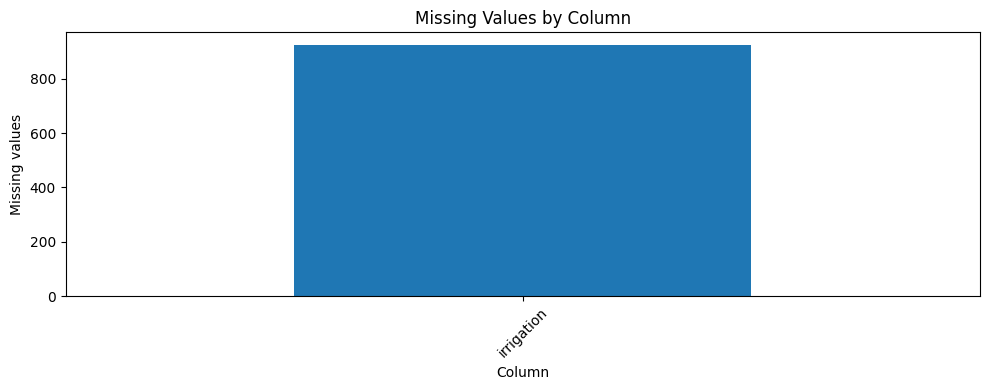

In [9]:
missing_summary = features_clean.isna().sum().sort_values(ascending=False).to_frame('missing_values')
display(missing_summary)
plot_missing_values(features_clean)


In [10]:
scale_summary = features_clean[BAND_COLS].describe().T
display(scale_summary)


,count,mean,std,min,25%,50%,75%,max
B1,6762.0,571.730750,144.691848,273.513837,475.105467,555.267537,641.849142,1600.252453
B2,6762.0,689.294502,188.695099,338.019907,561.885915,663.585642,778.836891,1999.314532
B3,6762.0,1016.196278,251.730386,548.950355,848.407098,977.176923,1126.626604,2785.676357
B4,6762.0,1342.593018,456.225115,473.776012,1015.927534,1309.839602,1588.386676,3774.324039
B5,6762.0,1720.391844,444.845514,808.047484,1409.619059,1674.879167,1955.757386,4159.790593
B6,6762.0,2406.632752,534.347007,930.073912,2056.305209,2426.863790,2774.963228,4233.112758
B7,6762.0,2711.157215,622.391408,1031.043337,2300.266096,2742.670088,3137.850073,4677.779961
B8,6762.0,2840.105745,645.032143,1123.517880,2421.941795,2858.847220,3287.920804,4847.667640
B8A,6762.0,2923.699222,626.422135,1191.573670,2518.286560,2939.078908,3361.200307,4844.863637
B9,6762.0,2931.217284,559.104897,1340.687053,2588.729682,2956.661942,3325.026136,4542.361989


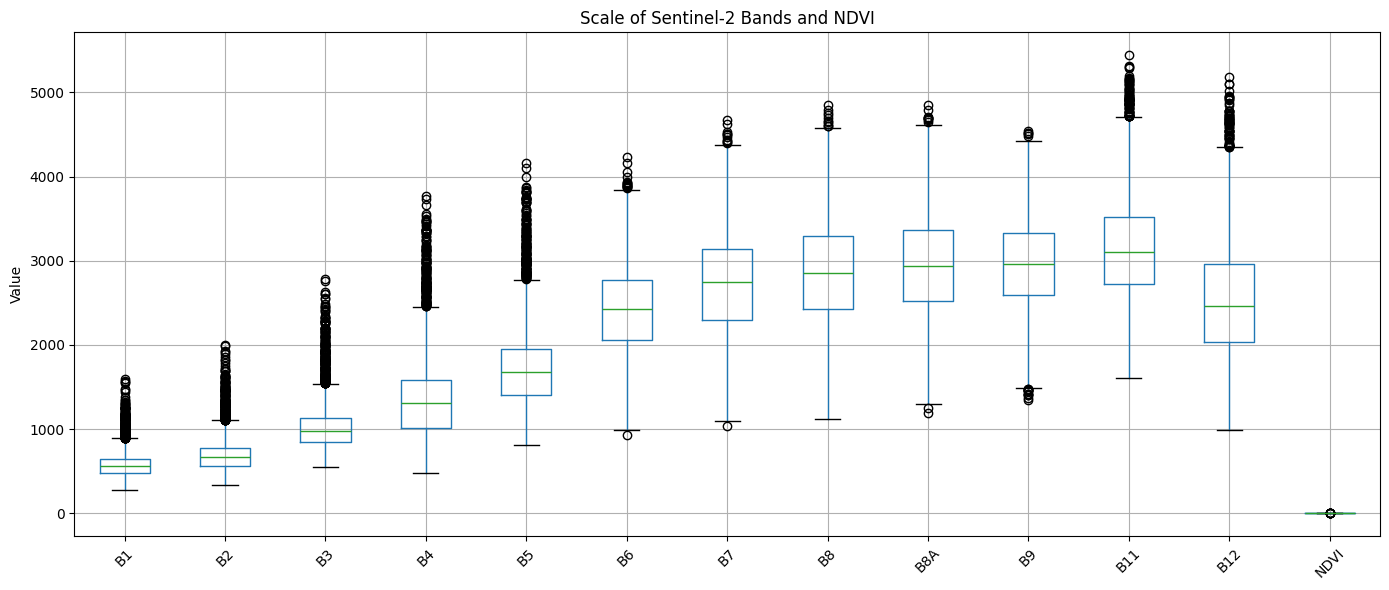

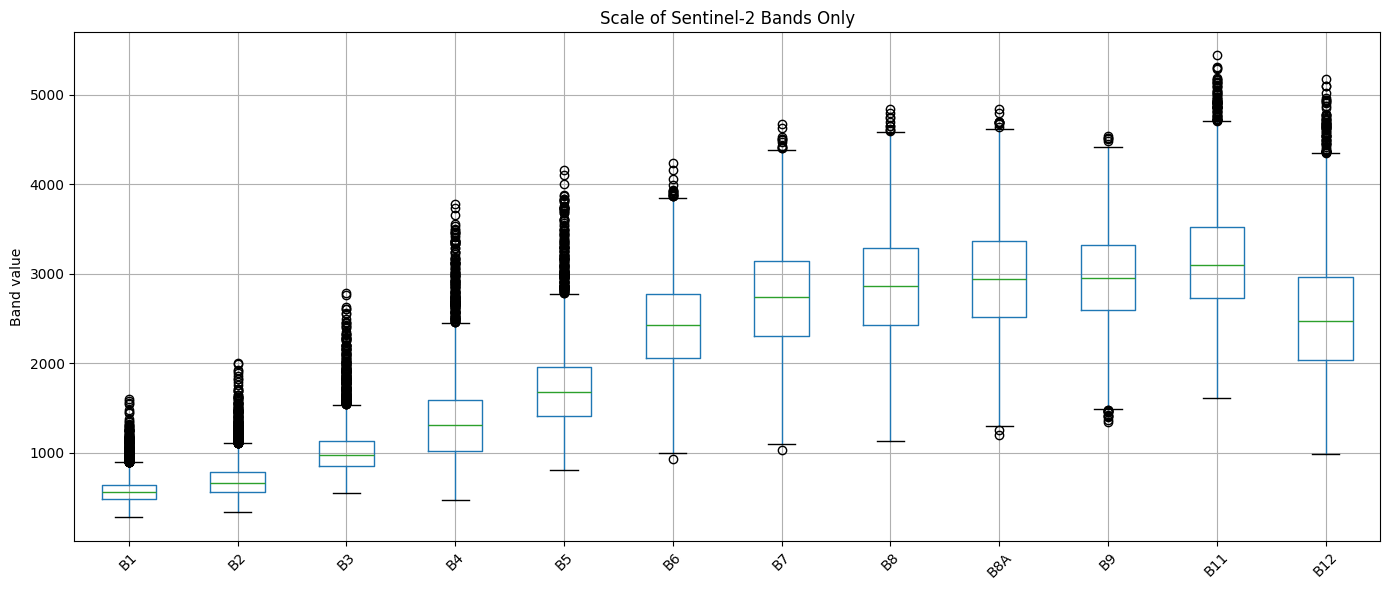

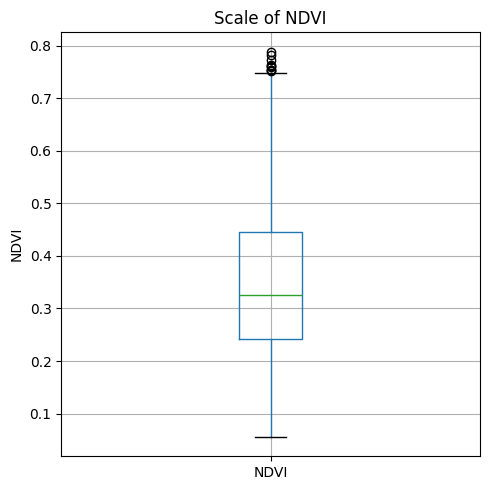

In [11]:
plt.figure(figsize=(14, 6))
features_clean[BAND_COLS].boxplot()
plt.xticks(rotation=45)
plt.title('Scale of Sentinel-2 Bands and NDVI')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
features_clean[REFLECTANCE_COLS].boxplot()
plt.xticks(rotation=45)
plt.title('Scale of Sentinel-2 Bands Only')
plt.ylabel('Band value')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
features_clean[['NDVI']].boxplot()
plt.title('Scale of NDVI')
plt.ylabel('NDVI')
plt.tight_layout()
plt.show()


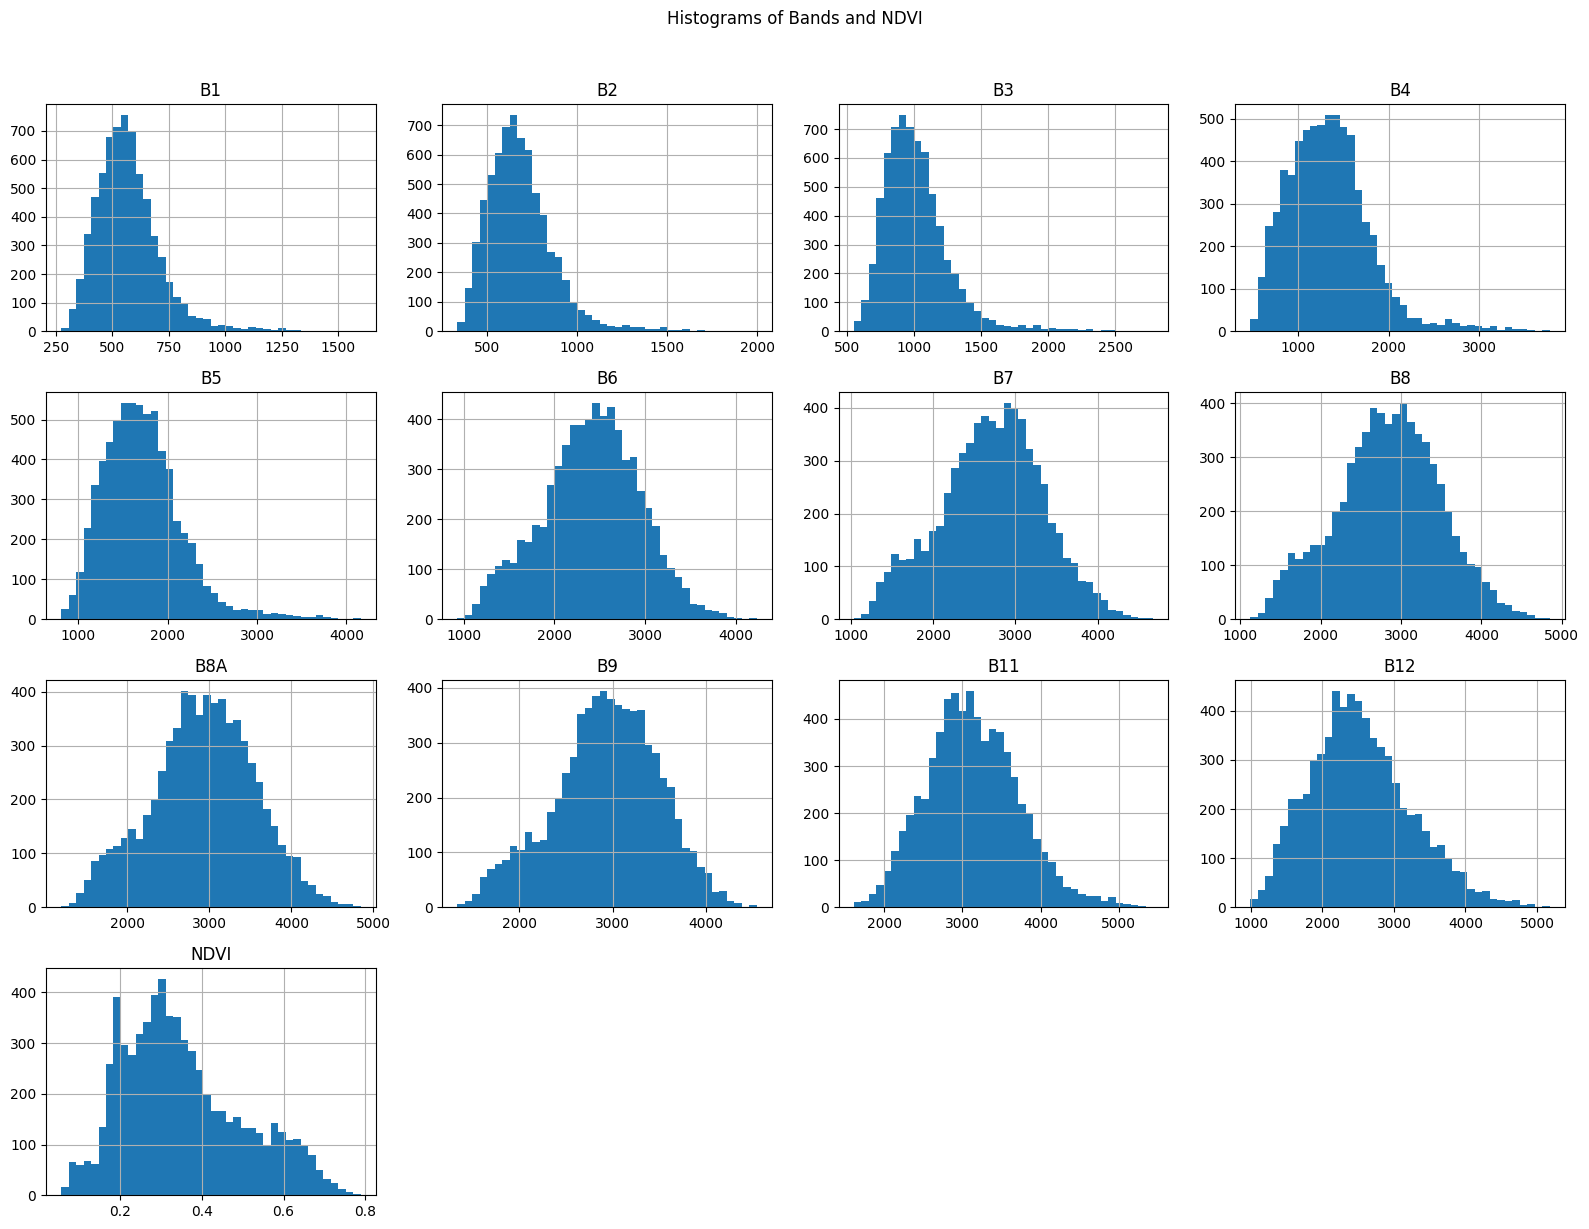

In [12]:
features_clean[BAND_COLS].hist(figsize=(16, 12), bins=40)
plt.suptitle('Histograms of Bands and NDVI', y=1.02)
plt.tight_layout()
plt.show()


class,corn,other_crop,soil,wheat
B1,539.558061,533.724845,648.111526,588.024956
B2,606.832295,615.457887,803.656887,742.771957
B3,886.880923,949.908662,1162.724069,1074.880152
B4,1064.541209,1149.074078,1687.833926,1496.013040
B5,1398.392107,1641.323659,1976.658630,1841.371028
B6,2105.867818,2728.630925,2267.382389,2360.170283
B7,2431.967295,3107.662472,2454.607901,2640.936848
B8,2534.480766,3265.135597,2546.143216,2774.706681
B8A,2623.390307,3327.462206,2629.919648,2871.585314
B9,2677.386202,3262.341234,2698.365112,2889.184790


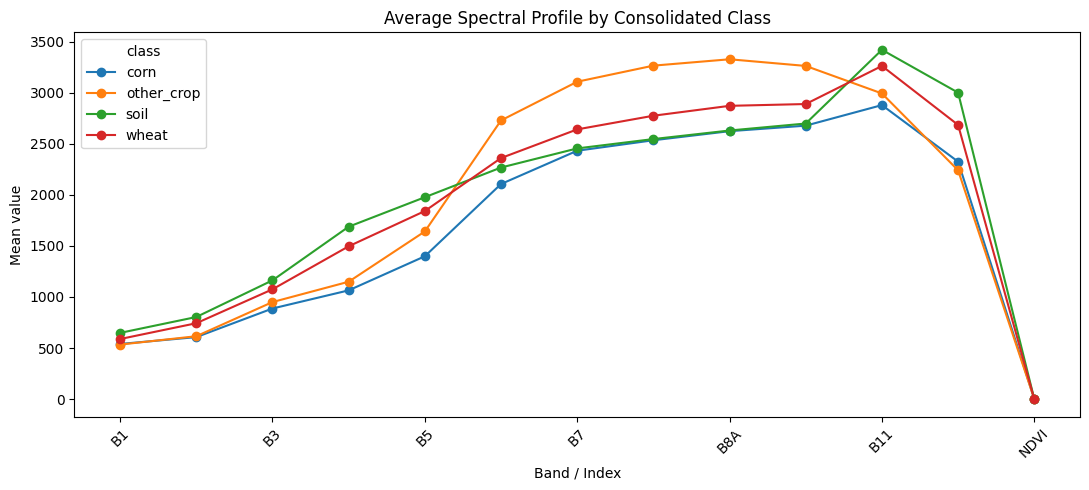

In [13]:
class_band_means = features_clean.groupby('class')[BAND_COLS].mean().T
display(class_band_means)

ax = class_band_means.plot(figsize=(11, 5), marker='o')
ax.set_title('Average Spectral Profile by Consolidated Class')
ax.set_xlabel('Band / Index')
ax.set_ylabel('Mean value')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


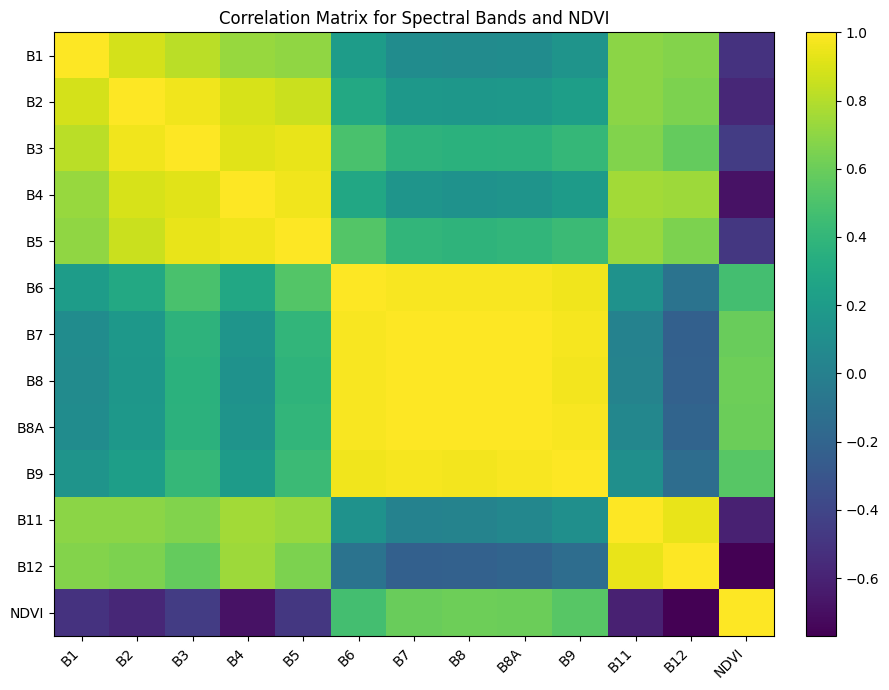

In [14]:
correlation_matrix = features_clean[BAND_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(correlation_matrix, aspect='auto')
ax.set_title('Correlation Matrix for Spectral Bands and NDVI')
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(correlation_matrix.index)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 7. Feature Engineering

The feature-engineering concept is preserved from the original notebook:

- Clip selected spectral columns at the 1st and 99th percentiles.
- Add water, built-up, vegetation, bare-soil, and ratio-based features.
- Use the same final feature list for XGBoost training.


In [15]:
df_model = features_clean.copy()

X_bands = df_model[COMMON_FEATURE_COLS].copy()
clip_lower = X_bands.quantile(0.01)
clip_upper = X_bands.quantile(0.99)

for col in COMMON_FEATURE_COLS:
    df_model[col] = df_model[col].clip(
        lower=clip_lower[col],
        upper=clip_upper[col]
    )

eps = 1e-6

# Spectral indices
df_model['NDWI'] = (df_model['B3'] - df_model['B8']) / (df_model['B3'] + df_model['B8'] + eps)
df_model['NDBI'] = (df_model['B11'] - df_model['B8']) / (df_model['B11'] + df_model['B8'] + eps)
df_model['SAVI'] = 1.5 * (df_model['B8'] - df_model['B4']) / (df_model['B8'] + df_model['B4'] + 0.5 + eps)

# Bare Soil Index
df_model['BSI'] = ((df_model['B11'] + df_model['B4']) - (df_model['B8'] + df_model['B2'])) / (
    (df_model['B11'] + df_model['B4']) + (df_model['B8'] + df_model['B2']) + eps
)

# Ratios that help separate bare soil from vegetation
df_model['B11_B8_ratio'] = df_model['B11'] / (df_model['B8'] + eps)
df_model['B4_B8_ratio'] = df_model['B4'] / (df_model['B8'] + eps)
df_model['B8_B4_diff'] = df_model['B8'] - df_model['B4']

FEATURE_COLS_V2 = COMMON_FEATURE_COLS + [
    'NDWI', 'NDBI', 'SAVI', 'BSI',
    'B11_B8_ratio', 'B4_B8_ratio', 'B8_B4_diff'
]

X_v2 = df_model[FEATURE_COLS_V2].copy()
y = df_model['class'].copy()

display(X_v2.head())
print(f'Number of modeling features: {len(FEATURE_COLS_V2)}')


,B2,B3,B4,B5,B6,B7,B8,B8A,B11,NDVI,NDWI,NDBI,SAVI,BSI,B11_B8_ratio,B4_B8_ratio,B8_B4_diff
0,798.593839,1032.651913,1372.857879,1572.294307,1707.351335,1851.199900,1979.984908,2083.750643,3635.551078,0.175744,-0.314453,0.294819,0.271577,0.286353,1.836151,0.693368,607.127028
1,648.792568,831.243794,1116.201914,1253.635502,1313.222512,1426.336494,1532.162035,1623.097112,2992.218838,0.157796,-0.296571,0.322709,0.235550,0.306464,1.952939,0.728514,415.960121
2,664.185252,865.152208,1174.222899,1315.857456,1382.017717,1495.075454,1611.860684,1691.850485,3127.308801,0.159373,-0.301455,0.319771,0.235578,0.307938,1.940186,0.728489,437.637785
3,713.456019,872.989335,1136.961460,1267.397322,1322.086087,1437.508268,1556.929807,1643.293917,2978.173760,0.157235,-0.281466,0.313387,0.233801,0.288896,1.912850,0.730259,419.968347
4,621.642510,844.452495,1213.038946,1364.782677,1431.619799,1553.620342,1675.869979,1756.679144,3237.494094,0.162244,-0.329885,0.317832,0.240273,0.319058,1.931829,0.723826,462.831033


Number of modeling features: 17


## 8. Baseline Weighted XGBoost Model

The first model uses the same weighted XGBoost approach from the original notebook. Class-balanced sample weights are used to reduce the effect of class imbalance.


In [16]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_v2,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train,
)

xgb_v2_weighted = XGBClassifier(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.025,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    gamma=0.1,
    reg_lambda=2,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
)

xgb_v2_weighted.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
)

y_pred = xgb_v2_weighted.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred)
print('Baseline weighted XGBoost accuracy:', baseline_accuracy)
print(classification_report(y_test, y_pred, target_names=le.classes_))


Baseline weighted XGBoost accuracy: 0.7398373983739838
              precision    recall  f1-score   support

        corn       0.73      0.80      0.77       251
  other_crop       0.75      0.79      0.77       391
        soil       0.58      0.57      0.57       188
       wheat       0.80      0.73      0.76       523

    accuracy                           0.74      1353
   macro avg       0.71      0.72      0.72      1353
weighted avg       0.74      0.74      0.74      1353



,corn,other_crop,soil,wheat
corn,202,17,13,19
other_crop,31,310,15,35
soil,17,20,107,44
wheat,25,66,50,382


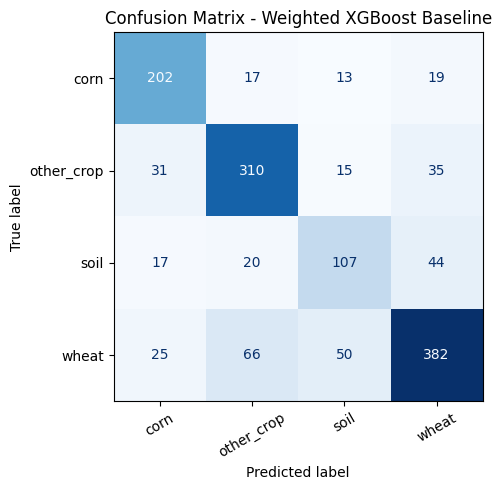

In [17]:
cm_df = plot_confusion_matrix(
    y_test,
    y_pred,
    class_names=le.classes_,
    title='Confusion Matrix - Weighted XGBoost Baseline',
)


## 9. Hyperparameter Tuning

Randomized search is used to explore XGBoost hyperparameters while preserving stratified class splits. The scoring metric is macro F1, which is appropriate when classes are imbalanced and each class should contribute meaningfully to evaluation.


In [18]:
sample_weights_all = compute_sample_weight(
    class_weight='balanced',
    y=y_encoded,
)

param_dist = {
    'n_estimators': [400, 600, 800],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.02, 0.03, 0.05],
    'subsample': [0.75, 0.85, 0.95],
    'colsample_bytree': [0.75, 0.85, 0.95],
    'min_child_weight': [1, 2, 4],
    'gamma': [0, 0.1, 0.3],
    'reg_lambda': [1, 2, 5],
}

base_xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=25,
    scoring='f1_macro',
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

search.fit(X_v2, y_encoded, sample_weight=sample_weights_all)

print('Best macro F1 score:', search.best_score_)
print('Best parameters:')
for key, value in search.best_params_.items():
    print(f'- {key}: {value}')


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best macro F1 score: 0.7305293112128431
Best parameters:
- subsample: 0.75
- reg_lambda: 2
- n_estimators: 800
- min_child_weight: 1
- max_depth: 4
- learning_rate: 0.05
- gamma: 0.3
- colsample_bytree: 0.95


,rank_test_score,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight,param_gamma,param_reg_lambda
24,1,0.730529,0.005112,800,4,0.05,0.75,0.95,1,0.3,2
22,2,0.728693,0.006476,800,5,0.02,0.85,0.95,2,0.1,1
6,3,0.727631,0.006469,600,4,0.05,0.85,0.95,4,0.1,1
12,4,0.727042,0.004019,800,4,0.03,0.75,0.95,4,0.3,2
23,5,0.726813,0.004019,400,5,0.05,0.95,0.95,2,0.0,1
20,6,0.726451,0.006055,800,3,0.05,0.85,0.95,1,0.1,2
11,7,0.724330,0.002424,600,5,0.03,0.85,0.95,4,0.1,5
7,8,0.720494,0.004359,400,5,0.03,0.85,0.95,2,0.3,1
13,9,0.719966,0.004331,600,3,0.05,0.75,0.85,2,0.1,5
16,10,0.719772,0.003778,800,4,0.02,0.85,0.75,2,0.0,2


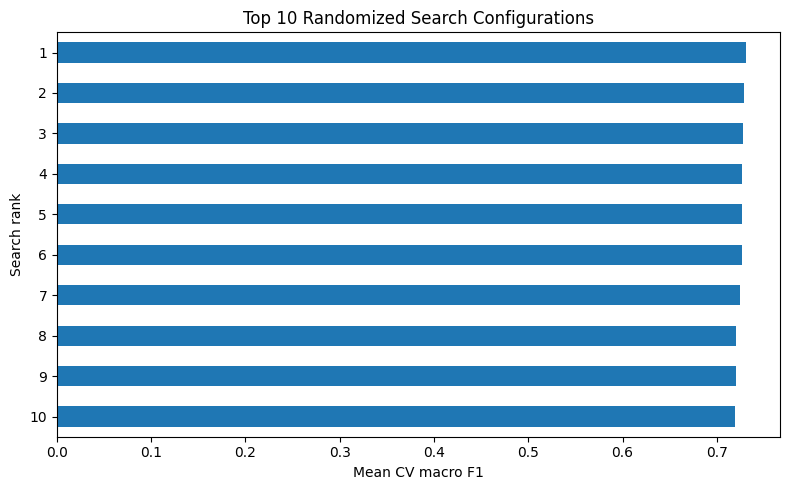

In [19]:
cv_results = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
summary_cols = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_n_estimators',
    'param_max_depth',
    'param_learning_rate',
    'param_subsample',
    'param_colsample_bytree',
    'param_min_child_weight',
    'param_gamma',
    'param_reg_lambda',
]
display(cv_results[summary_cols].head(10))

plot_cv = cv_results.head(10).sort_values('mean_test_score')
ax = plot_cv.plot(kind='barh', x='rank_test_score', y='mean_test_score', figsize=(8, 5), legend=False)
ax.set_title('Top 10 Randomized Search Configurations')
ax.set_xlabel('Mean CV macro F1')
ax.set_ylabel('Search rank')
plt.tight_layout()
plt.show()


## 10. Final Tuned Model Evaluation

The best estimator from randomized search is retrained on the training split and evaluated on the held-out test split.


Final tuned XGBoost accuracy: 0.7531411677753141
              precision    recall  f1-score   support

        corn       0.75      0.81      0.78       251
  other_crop       0.78      0.82      0.80       391
        soil       0.56      0.55      0.55       188
       wheat       0.80      0.75      0.77       523

    accuracy                           0.75      1353
   macro avg       0.72      0.73      0.73      1353
weighted avg       0.75      0.75      0.75      1353



,corn,other_crop,soil,wheat
corn,204,15,14,18
other_crop,23,320,16,32
soil,18,20,104,46
wheat,26,53,53,391


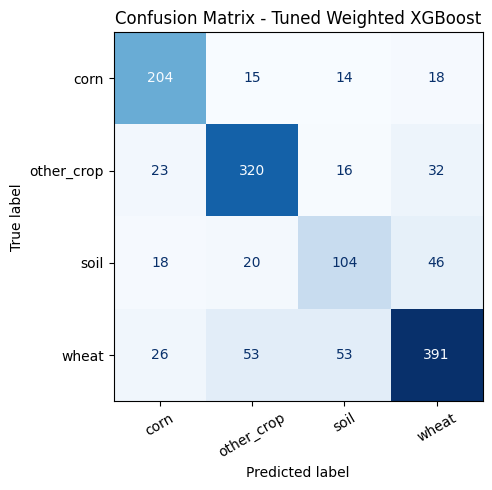

In [20]:
best_xgb = search.best_estimator_

best_xgb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_best = best_xgb.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_best)
print('Final tuned XGBoost accuracy:', final_accuracy)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

cm_best_df = plot_confusion_matrix(
    y_test,
    y_pred_best,
    class_names=le.classes_,
    title='Confusion Matrix - Tuned Weighted XGBoost',
)


## 11. Feature Importance

Feature importance helps explain which spectral bands and engineered indices contribute most to the tuned model.


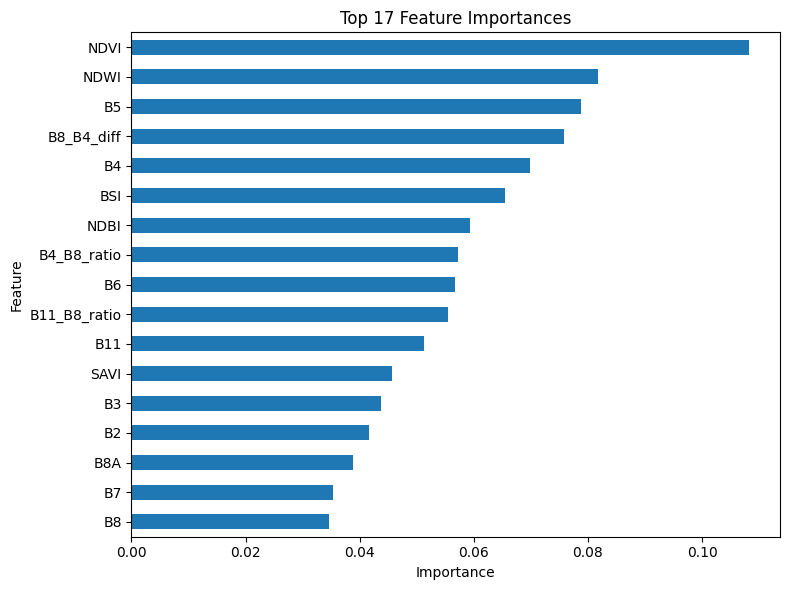

,feature,importance,rank
0,NDVI,0.108231,1
1,NDWI,0.081683,2
2,B5,0.078757,3
3,B8_B4_diff,0.075817,4
4,B4,0.069927,5
5,BSI,0.065465,6
6,NDBI,0.059340,7
7,B4_B8_ratio,0.057290,8
8,B6,0.056769,9
9,B11_B8_ratio,0.055508,10


In [21]:
feature_importance = plot_feature_importance(best_xgb, FEATURE_COLS_V2, top_n=len(FEATURE_COLS_V2))
display(feature_importance)


## 12. Save Model Artifacts

The trained model, label encoder, selected feature columns, and clipping thresholds are saved for later inference or deployment.


In [22]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_xgb, OUTPUT_DIR / 'xgb_tuned_v2_indices_weighted.pkl')
joblib.dump(le, OUTPUT_DIR / 'label_encoder_v2.pkl')
joblib.dump(FEATURE_COLS_V2, OUTPUT_DIR / 'feature_cols_v2.pkl')
joblib.dump(clip_lower, OUTPUT_DIR / 'clip_lower_common.pkl')
joblib.dump(clip_upper, OUTPUT_DIR / 'clip_upper_common.pkl')

print(f'Saved tuned model and preprocessing artifacts to: {OUTPUT_DIR}')


Saved tuned model and preprocessing artifacts to: /content/drive/MyDrive/morocco_clean_outputs


In [23]:
# Optional smoke test: reload saved artifacts and confirm they are available.
loaded_model = joblib.load(OUTPUT_DIR / 'xgb_tuned_v2_indices_weighted.pkl')
loaded_encoder = joblib.load(OUTPUT_DIR / 'label_encoder_v2.pkl')
loaded_features = joblib.load(OUTPUT_DIR / 'feature_cols_v2.pkl')

print(type(loaded_model))
print('Classes:', list(loaded_encoder.classes_))
print('Number of loaded features:', len(loaded_features))


<class 'xgboost.sklearn.XGBClassifier'>
Classes: ['corn', 'other_crop', 'soil', 'wheat']
Number of loaded features: 17


## 13. Summary

This notebook provides a professionalized version of the original XGBoost workflow without changing the core concept.

### Key modeling choices preserved
- Four-class crop/land-cover target consolidation.
- Sentinel-2 spectral bands and NDVI as core inputs.
- Additional engineered indices and ratios.
- Class-balanced sample weighting.
- XGBoost multiclass classification.
- Randomized hyperparameter search with stratified cross-validation.
- Saved model artifacts for reuse.

### Recommended next steps
- Validate the final model on a separate geographic or temporal holdout dataset.
- Track results in a dedicated experiment log.
- Add inference code that applies the same clipping and feature engineering to new field samples.
- Consider spatial cross-validation if field locations are strongly clustered.
